In [1]:
import numpy as np
import pandas as pd

import pypsa

In [ ]:
# del(grid)

In [43]:
grid = pypsa.Network()

In [44]:
S_default=1 # MVA

S_base=100 # MVA
V_base=1 # kV

Z_base = V_base**2 / S_base # Ohm

In [45]:
grid.add("Bus", "Bus 1", v_nom=V_base, v_mag_pu_set=1.06, control="Slack")
grid.add("Bus", "Bus 2", v_nom=V_base, v_mag_pu_set=1.00)
grid.add("Bus", "Bus 3", v_nom=V_base, v_mag_pu_set=1.00)
grid.add("Bus", "Bus 4", v_nom=V_base, v_mag_pu_set=1.00)
grid.add("Bus", "Bus 5", v_nom=V_base, v_mag_pu_set=1.00)

grid.buses

,v_nom,type,x,y,carrier,unit,location,v_mag_pu_set,v_mag_pu_min,v_mag_pu_max,control,generator,sub_network
name,,,,,,,,,,,,,
Bus 1,1.0,,0.0,0.0,AC,,,1.06,0.0,inf,Slack,,
Bus 2,1.0,,0.0,0.0,AC,,,1.00,0.0,inf,PQ,,
Bus 3,1.0,,0.0,0.0,AC,,,1.00,0.0,inf,PQ,,
Bus 4,1.0,,0.0,0.0,AC,,,1.00,0.0,inf,PQ,,
Bus 5,1.0,,0.0,0.0,AC,,,1.00,0.0,inf,PQ,,


In [46]:
grid.add("Line", "Line 12", bus0="Bus 1", bus1="Bus 2", r=0.02*(V_base**2), x=0.06*(V_base**2), b=0.030*2/(V_base**2))
grid.add("Line", "Line 13", bus0="Bus 1", bus1="Bus 3", r=0.08*(V_base**2), x=0.24*(V_base**2), b=0.025*2/(V_base**2))
grid.add("Line", "Line 23", bus0="Bus 2", bus1="Bus 3", r=0.06*(V_base**2), x=0.25*(V_base**2), b=0.020*2/(V_base**2))
grid.add("Line", "Line 24", bus0="Bus 2", bus1="Bus 4", r=0.06*(V_base**2), x=0.18*(V_base**2), b=0.020*2/(V_base**2))
grid.add("Line", "Line 25", bus0="Bus 2", bus1="Bus 5", r=0.04*(V_base**2), x=0.12*(V_base**2), b=0.015*2/(V_base**2))
grid.add("Line", "Line 34", bus0="Bus 3", bus1="Bus 4", r=0.01*(V_base**2), x=0.03*(V_base**2), b=0.010*2/(V_base**2))
grid.add("Line", "Line 45", bus0="Bus 4", bus1="Bus 5", r=0.08*(V_base**2), x=0.24*(V_base**2), b=0.025*2/(V_base**2))

grid.lines

,bus0,bus1,type,x,r,g,b,s_nom,s_nom_mod,s_nom_extendable,...,v_ang_min,v_ang_max,sub_network,x_pu,r_pu,g_pu,b_pu,x_pu_eff,r_pu_eff,s_nom_opt
name,,,,,,,,,,,,,,,,,,,,,
Line 12,Bus 1,Bus 2,,0.06,0.02,0.0,0.06,0.0,0.0,False,...,-inf,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Line 13,Bus 1,Bus 3,,0.24,0.08,0.0,0.05,0.0,0.0,False,...,-inf,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Line 23,Bus 2,Bus 3,,0.25,0.06,0.0,0.04,0.0,0.0,False,...,-inf,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Line 24,Bus 2,Bus 4,,0.18,0.06,0.0,0.04,0.0,0.0,False,...,-inf,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Line 25,Bus 2,Bus 5,,0.12,0.04,0.0,0.03,0.0,0.0,False,...,-inf,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Line 34,Bus 3,Bus 4,,0.03,0.01,0.0,0.02,0.0,0.0,False,...,-inf,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Line 45,Bus 4,Bus 5,,0.24,0.08,0.0,0.05,0.0,0.0,False,...,-inf,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [47]:
grid.add("Generator", "Generator 1", bus="Bus 1", control="Slack")
grid.add("Generator", "Generator 2", bus="Bus 2", p_set=40.0/S_base, q_set=30.0/S_base, control="PQ")

grid.generators

,bus,control,type,p_nom,p_nom_mod,p_nom_extendable,p_nom_min,p_nom_max,p_nom_set,p_min_pu,...,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,weight,p_nom_opt
name,,,,,,,,,,,,,,,,,,,,,
Generator 1,Bus 1,Slack,,0.0,0.0,False,0.0,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,0.0
Generator 2,Bus 2,PQ,,0.0,0.0,False,0.0,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,0.0


In [48]:
grid.add("Load", "Load 2", bus="Bus 2", p_set=20/S_base, q_set=10/S_base)
grid.add("Load", "Load 3", bus="Bus 3", p_set=45/S_base, q_set=15/S_base)
grid.add("Load", "Load 4", bus="Bus 4", p_set=40/S_base, q_set=5/S_base)
grid.add("Load", "Load 5", bus="Bus 5", p_set=60/S_base, q_set=10/S_base)

grid.loads

,bus,carrier,type,p_set,q_set,sign,active
name,,,,,,,
Load 2,Bus 2,,,0.20,0.10,-1.0,True
Load 3,Bus 3,,,0.45,0.15,-1.0,True
Load 4,Bus 4,,,0.40,0.05,-1.0,True
Load 5,Bus 5,,,0.60,0.10,-1.0,True


In [49]:
grid.lpf()
grid.pf(use_seed=True)

# grid.pf()

INFO:pypsa.network.power_flow:Performing linear load-flow on AC sub-network <pypsa.networks.SubNetwork object at 0x00000285D682D100> for snapshot(s) Index(['now'], dtype='object', name='snapshot')
INFO:pypsa.network.power_flow:Performing non-linear load-flow on AC sub-network <pypsa.networks.SubNetwork object at 0x00000285D637D640> for snapshots Index(['now'], dtype='object', name='snapshot')


{'n_iter': name      0
 snapshot   
 now       3,
 'error': name                 0
 snapshot              
 now       1.865654e-09,
 'converged': name         0
 snapshot      
 now       True}

In [50]:
now = grid.snapshots[0]

angle_diff = pd.Series(grid.buses_t.v_ang.loc[now,grid.lines.bus0].values -
                       grid.buses_t.v_ang.loc[now,grid.lines.bus1].values,
                       index=grid.lines.index)

(angle_diff*180/np.pi).describe()

count    7.000000
mean     2.503585
std      1.660349
min      0.279265
25%      1.567501
50%      2.735026
75%      3.083577
max      5.208649
dtype: float64

{'nodes': {'Bus': <matplotlib.collections.PatchCollection at 0x285d66eb8f0>},
 'branches': {'Line': <matplotlib.collections.LineCollection at 0x285d66ea3c0>},
 'flows': {}}

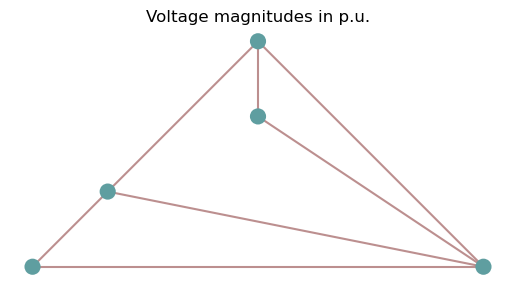

In [51]:
grid.plot(bus_sizes=1e-3, title="Voltage magnitudes in p.u.")

In [52]:
grid.branches()

active     b  b_pu  build_year   bus0   bus1  capital_cost  \
component name                                                                  
Line      Line 12    True  0.06  0.06           0  Bus 1  Bus 2           0.0   
          Line 13    True  0.05  0.05           0  Bus 1  Bus 3           0.0   
          Line 23    True  0.04  0.04           0  Bus 2  Bus 3           0.0   
          Line 24    True  0.04  0.04           0  Bus 2  Bus 4           0.0   
          Line 25    True  0.03  0.03           0  Bus 2  Bus 5           0.0   
          Line 34    True  0.02  0.02           0  Bus 3  Bus 4           0.0   
          Line 45    True  0.05  0.05           0  Bus 4  Bus 5           0.0   

                  carrier committable  down_time_before  ...  tap_side  \
component name                                           ...             
Line      Line 12      AC         NaN               NaN  ...       NaN   
          Line 13      AC         NaN               NaN  ...       NaN   
          Line 23      AC         NaN               NaN  ...       NaN   
          Line 24      AC         NaN               NaN  ...       NaN   
          Line 25      AC         NaN               NaN  ...       NaN   
          Line 34      AC         NaN               NaN  ...       NaN   
          Line 45      AC         NaN               NaN  ...       NaN   

                   terrain_factor  type  up_time_before  v_ang_max  v_ang_min  \
component name                                                                  
Line      Line 12             1.0                   NaN        inf       -inf   
          Line 13             1.0                   NaN        inf       -inf   
          Line 23             1.0                   NaN        inf       -inf   
          Line 24             1.0                   NaN        inf       -inf   
          Line 25             1.0                   NaN        inf       -inf   
          Line 34             1.0                   NaN        inf       -inf   
          Line 45             1.0                   NaN        inf       -inf   

                   v_nom     x  x_pu x_pu_eff  
component name                                 
Line      Line 12    1.0  0.06  0.06     0.06  
          Line 13    1.0  0.24  0.24     0.24  
          Line 23    1.0  0.25  0.25     0.25  
          Line 24    1.0  0.18  0.18     0.18  
          Line 25    1.0  0.12  0.12     0.12  
          Line 34    1.0  0.03  0.03     0.03  
          Line 45    1.0  0.24  0.24     0.24  

[7 rows x 63 columns]

In [53]:
grid.generators_t.p

name,Generator 1,Generator 2
snapshot,,
now,NaN,0.4


In [54]:
grid.generators_t.q

name,Generator 1,Generator 2
snapshot,,
now,-0.070477,0.3


In [55]:
grid.loads_t.p

name,Load 2,Load 3,Load 4,Load 5
snapshot,,,,
now,0.2,0.45,0.4,0.6


In [56]:
grid.loads_t.q

name,Load 2,Load 3,Load 4,Load 5
snapshot,,,,
now,0.1,0.15,0.05,0.1


In [57]:
grid.buses

,v_nom,type,x,y,carrier,unit,location,v_mag_pu_set,v_mag_pu_min,v_mag_pu_max,control,generator,sub_network
name,,,,,,,,,,,,,
Bus 1,1.0,,0.0,0.0,AC,,,1.06,0.0,inf,Slack,Generator 1,0
Bus 2,1.0,,0.0,0.0,AC,,,1.00,0.0,inf,PQ,,0
Bus 3,1.0,,0.0,0.0,AC,,,1.00,0.0,inf,PQ,,0
Bus 4,1.0,,0.0,0.0,AC,,,1.00,0.0,inf,PQ,,0
Bus 5,1.0,,0.0,0.0,AC,,,1.00,0.0,inf,PQ,,0


In [58]:
grid.buses_t.p * S_base

name,Bus 1,Bus 2,Bus 3,Bus 4,Bus 5
snapshot,,,,,
now,129.611679,20.0,-45.0,-40.0,-60.0


In [59]:
grid.buses_t.q * S_base

name,Bus 1,Bus 2,Bus 3,Bus 4,Bus 5
snapshot,,,,,
now,-7.047667,20.0,-15.0,-5.0,-10.0


In [60]:
grid.buses_t.v_mag_pu

name,Bus 1,Bus 2,Bus 3,Bus 4,Bus 5
snapshot,,,,,
now,1.06,1.047578,1.022892,1.022541,1.017641


In [61]:
grid.buses_t.v_ang * 180 / np.pi

name,Bus 1,Bus 2,Bus 3,Bus 4,Bus 5
snapshot,,,,,
now,0.0,-2.752888,-5.208649,-5.487914,-6.167155
